# EDA — Predicting Electric Vehicle Purchases

Playground Series (2026). Target: `Will_Buy_EV` (Yes/No), evaluated on ROC AUC.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

TARGET = "Will_Buy_EV"

In [2]:
train = pd.read_csv("playground-series-s6e9/train.csv")
test = pd.read_csv("playground-series-s6e9/test.csv")

print("train:", train.shape)
print("test: ", test.shape)
train.head()

train: (668665, 15)
test:  (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


## Data overview

Dtypes, nulls, duplicates, and unique-value counts.

In [3]:
summary = pd.DataFrame({
    "dtype": train.dtypes,
    "n_missing": train.isnull().sum(),
    "pct_missing": (train.isnull().mean() * 100).round(2),
    "n_unique": train.nunique(),
})
print("duplicate rows:", train.duplicated().shape[0] - train.drop_duplicates().shape[0])
summary

duplicate rows: 0


,dtype,n_missing,pct_missing,n_unique
id,int64,0,0.0,668665
Age,int64,0,0.0,45
Annual_Income_USD,float64,0,0.0,13214
Daily_Commute_km,float64,0,0.0,805
Number_of_Cars_Owned,int64,0,0.0,4
Charging_Stations_Near_Home,int64,0,0.0,15
Charging_Stations_Near_Work,int64,0,0.0,20
Environmental_Concern_Level,float64,0,0.0,5
Gender,object,0,0.0,3
City_Type,object,0,0.0,3


## Target distribution

`Will_Buy_EV` is Yes/No — check class balance since it affects CV strategy and metric behavior.

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64
Will_Buy_EV
No     0.8254
Yes    0.1746
Name: proportion, dtype: float64


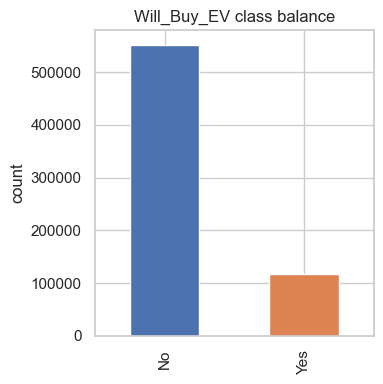

In [4]:
y = (train[TARGET] == "Yes").astype(int)

print(train[TARGET].value_counts())
print(train[TARGET].value_counts(normalize=True).round(4))

fig, ax = plt.subplots(figsize=(4, 4))
train[TARGET].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Will_Buy_EV class balance")
ax.set_xlabel("")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## Numeric features

`Age`, `Annual_Income_USD`, `Daily_Commute_km`, `Number_of_Cars_Owned`, `Charging_Stations_Near_Home`, `Charging_Stations_Near_Work`, `Environmental_Concern_Level`.

In [5]:
numeric_cols = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level",
]
train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


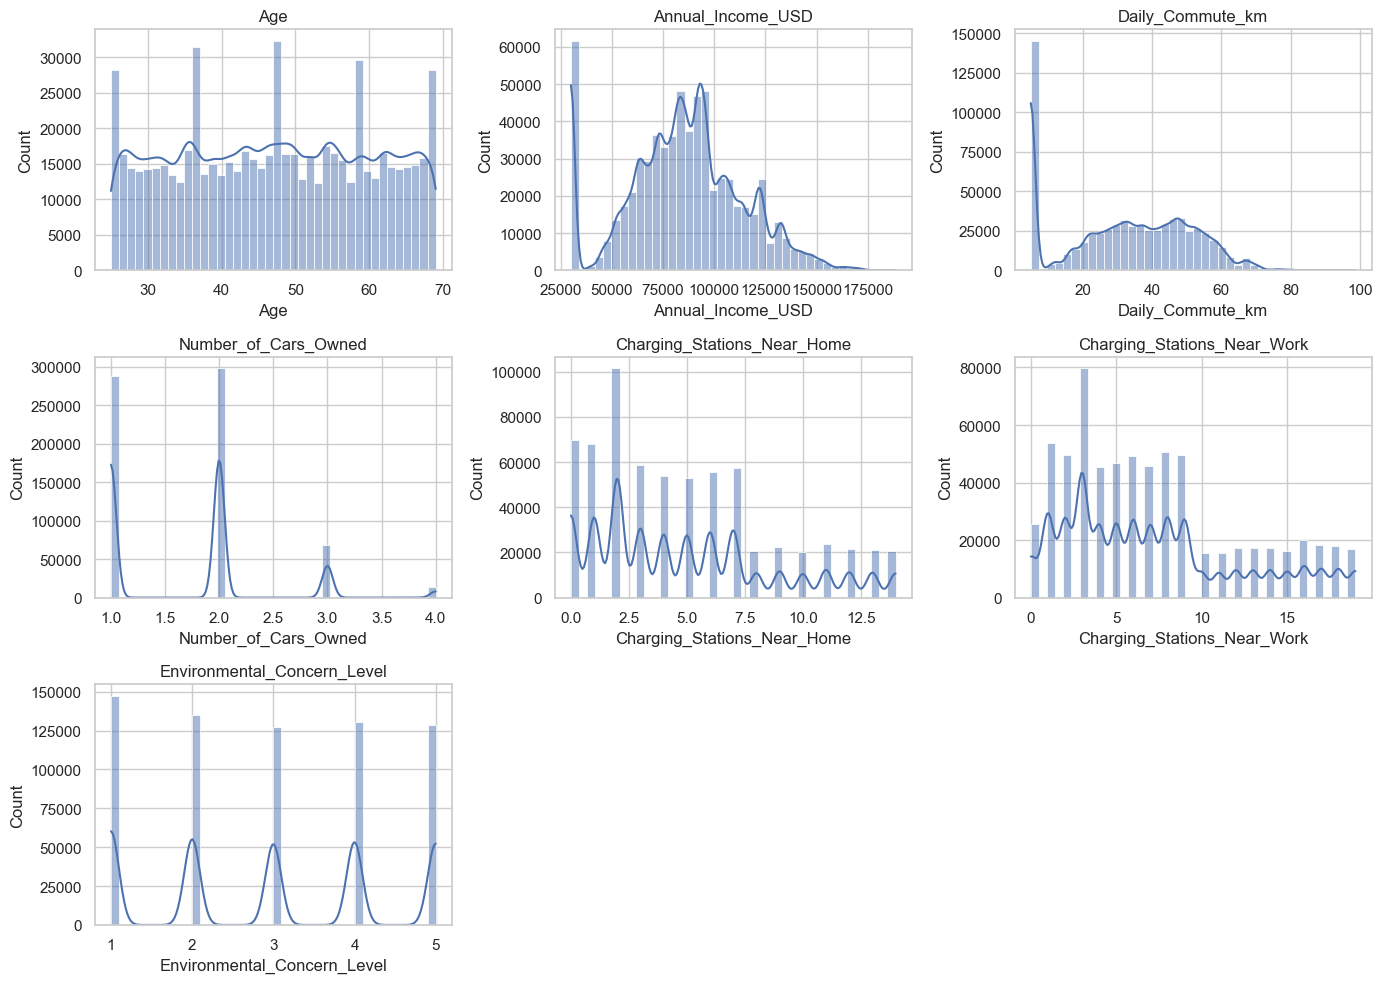

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(train[col], bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
for ax in axes.flat[len(numeric_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Numeric features vs target

Distribution of each numeric feature split by `Will_Buy_EV`.

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=train, x=TARGET, y=col, ax=ax, order=["No", "Yes"], palette=["#4C72B0", "#DD8452"])
    ax.set_title(col)
for ax in axes.flat[len(numeric_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Categorical features

`Gender`, `City_Type`, `Current_Car_Type`, `Home_Charging_Possible`, `Subsidy_Available`, `Range_Anxiety_Level`.

In [8]:
categorical_cols = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level",
]
for col in categorical_cols:
    print(f"--- {col} ---")
    print(train[col].value_counts())
    print()

--- Gender ---
Gender
Male      367954
Female    295427
Other       5284
Name: count, dtype: int64

--- City_Type ---
City_Type
Urban       289305
Suburban    255377
Rural       123983
Name: count, dtype: int64

--- Current_Car_Type ---
Current_Car_Type
Sedan        303459
SUV          246545
Hatchback     79438
Truck         39223
Name: count, dtype: int64

--- Home_Charging_Possible ---
Home_Charging_Possible
Yes    462677
No     205988
Name: count, dtype: int64

--- Subsidy_Available ---
Subsidy_Available
Yes    419909
No     248756
Name: count, dtype: int64

--- Range_Anxiety_Level ---
Range_Anxiety_Level
Low       603972
Medium     62499
High        2194
Name: count, dtype: int64



### Categorical features vs target

`Will_Buy_EV` rate within each category — a quick read on which categories skew the purchase probability.

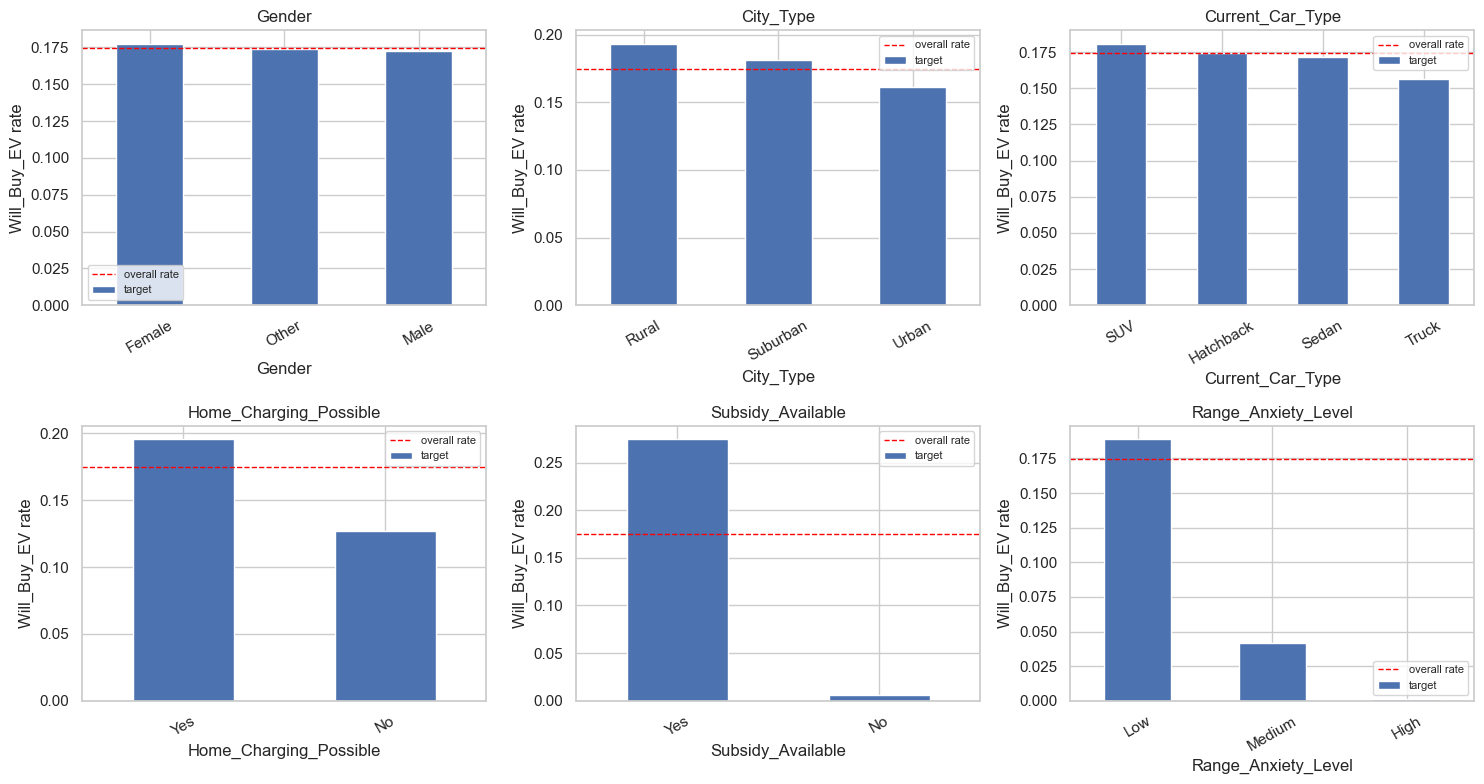

In [9]:
overall_rate = y.mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, categorical_cols):
    rate = train.assign(target=y).groupby(col)["target"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#4C72B0")
    ax.axhline(overall_rate, color="red", linestyle="--", linewidth=1, label="overall rate")
    ax.set_title(col)
    ax.set_ylabel("Will_Buy_EV rate")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Correlation

Numeric features plus the binary target.

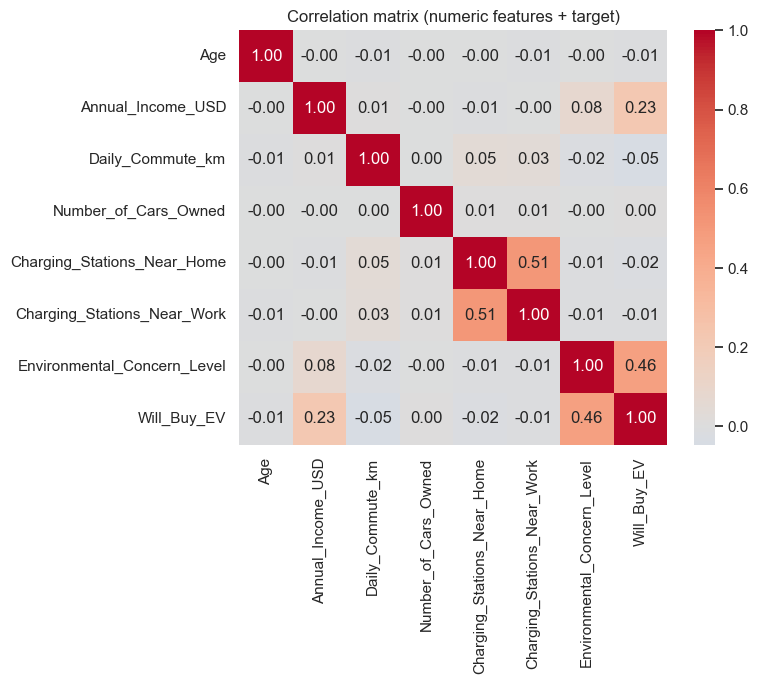

In [10]:
corr = train[numeric_cols].assign(Will_Buy_EV=y).corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (numeric features + target)")
plt.tight_layout()
plt.show()

## Train vs test consistency

Check numeric feature ranges/means line up between train and test (no distribution shift), and that `test` has no target column.

In [11]:
print("target in test columns:", TARGET in test.columns)
print("test id range:", test["id"].min(), "-", test["id"].max())

compare = pd.concat(
    [train[numeric_cols].mean().rename("train_mean"), test[numeric_cols].mean().rename("test_mean")],
    axis=1,
)
compare["diff_pct"] = ((compare["test_mean"] - compare["train_mean"]) / compare["train_mean"] * 100).round(2)
compare

target in test columns: False
test id range: 668665 - 955235


,train_mean,test_mean,diff_pct
Age,47.039171,47.070824,0.07
Annual_Income_USD,84769.266989,84799.508432,0.04
Daily_Commute_km,32.158298,32.159305,0.00
Number_of_Cars_Owned,1.712626,1.716095,0.20
Charging_Stations_Near_Home,4.960408,4.950693,-0.20
Charging_Stations_Near_Work,7.176314,7.155626,-0.29
Environmental_Concern_Level,2.935477,2.934554,-0.03
